In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.sample(10)

,Survived,Age,Fare
326,0,61.00,6.2375
305,1,0.92,151.5500
380,1,42.00,227.5250
516,1,34.00,10.5000
413,0,NaN,0.0000
104,0,37.00,7.9250
520,1,30.00,93.5000
452,0,30.00,27.7500
661,0,40.00,7.2250
21,1,34.00,13.0000


In [9]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [11]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [15]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [39]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [41]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [43]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\parvez\AppData\Local\Temp\ipykernel_12376\3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


In [45]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([24. , 24. , 57. , 29. , 29. , 56. , 19. , 29. , 49. , 24. , 35. ,
       15. , 22. , 14. , 46. , 35. , 47. , 40. , 24. , 28. , 18. , 21. ,
       27. , 28. ,  5. , 20. , 36. , 20. , 26. ,  9. , 34. , 11. , 50. ,
       22. , 45. , 19. , 25. ,  9. , 24. ,  3. , 32. , 17. , 29. ,  2. ,
       18. , 62. , 54. , 26. , 30. , 31. , 44. , 27. ,  9. ,  9. , 33. ,
       45.5, 14. , 18. , 46. , 24. , 25. , 19. , 54. , 11. , 28. , 41. ,
       16. , 31. , 16. , 45.5, 16. , 37. , 32. , 25. , 36. , 23. , 20. ,
       48. , 59. , 30. , 18. , 28. , 49. , 36. ,  2. , 23. , 62. , 24. ,
        2. , 20. , 17. , 47. , 60. , 22. , 31. , 19. , 21. , 19. , 48. ,
       32. , 16. ,  4. , 25. , 39. , 39. , 29. , 36. , 29. , 29. ,  4. ,
        1. , 51. , 15. , 25. , 32. , 33. ,  4. , 34. , 22. , 30. , 40. ,
       21. , 24. , 16. , 26. , 17. , 54. , 30. , 22. , 43. ,  2. , 24. ,
       41. , 31. , 30. , 45. , 16. , 62. , 29. , 24. , 35. , 35. , 34. ,
       51. , 30. , 42. , 16. , 45. ])

In [47]:
X_train['Age'].isnull().sum()

148

In [49]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,29.0
493,71.0,49.5042,71.0
527,NaN,221.7792,29.0


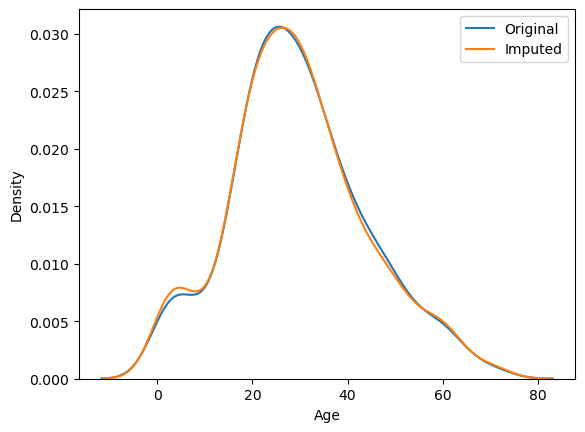

In [63]:
sns.kdeplot(X_train['Age'],label='Original')
sns.kdeplot(X_train['Age_imputed'],label = 'Imputed')

plt.legend()
plt.show()

In [65]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  209.0642745966279


In [69]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,50.860388
Age,71.512440,204.349513,204.349513
Age_imputed,50.860388,204.349513,209.064275


<Axes: >

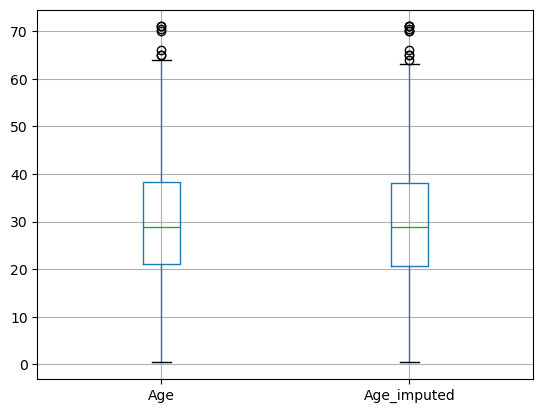

In [71]:
X_train[['Age', 'Age_imputed']].boxplot()

In [75]:
# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

In [77]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [79]:
data

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [81]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [83]:
X = data
y = data['SalePrice']

In [85]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [93]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [95]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1068,Gd,TA,151400,TA,Gd
1409,TA,TA,215000,TA,TA
898,Gd,TA,611657,TA,Gd
1139,Gd,TA,144000,TA,Gd
449,NaN,TA,120000,TA,NaN


In [97]:
X_train[X_train['GarageQual_imputed'].isnull()]['GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test[X_test['GarageQual_imputed'].isnull()]['GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train[X_train['FireplaceQu_imputed'].isnull()]['FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test[X_test['FireplaceQu_imputed'].isnull()]['FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\parvez\AppData\Local\Temp\ipykernel_12376\2367934036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[X_train['GarageQual_imputed'].isnull()]['GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
C:\Users\parvez\AppData\Local\Temp\ipykernel_12376\2367934036.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[X_test['GarageQual_imputed'].isnull()]['GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].

In [99]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

In [101]:
temp.columns = ['original', 'imputed']

In [103]:
temp

,original,imputed
TA,0.951043,0.898116
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [105]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.338945
TA,0.412439,0.282828
Fa,0.040917,0.028058
Po,0.027823,0.019080
Ex,0.024550,0.016835


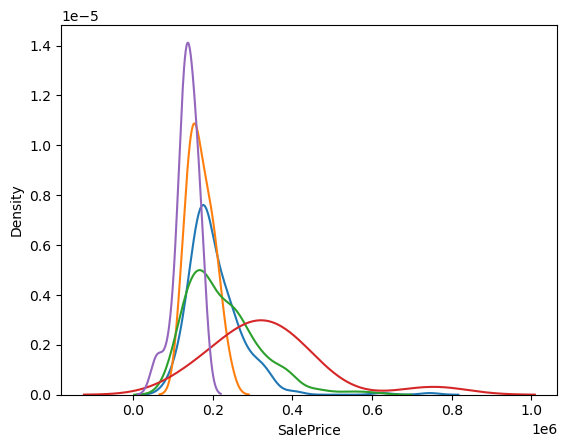

In [111]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.show()

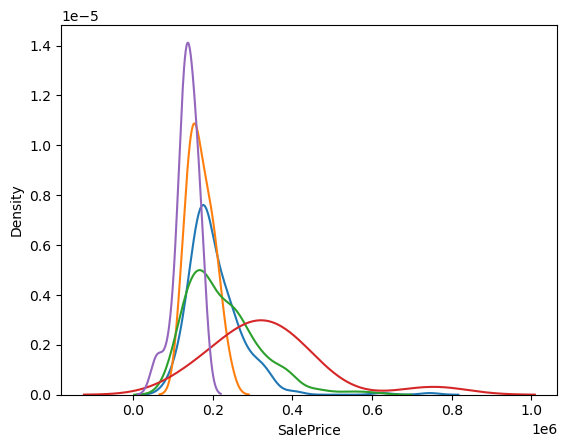

In [118]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.show()